# TP3 - Análisis de Sentimiento sobre Tweets (Sentiment140)
## Notebook 5 — Tópicos, Embeddings, PMI y Grafos (con evolución temporal)
### Diplomatura IA - UP
### Alumno: Gonzalez Marta Elizabeth
### Mes: Julio26

1. BERTopic ahora se ajusta sobre una **muestra** del megaset y se propaga (`transform`) al resto — ajustar UMAP/HDBSCAN sobre 1.6M+ documentos completos no es viable en este equipo de hogar (se comprobamos anteriormente y llevo varias horas de cómputo / cuelgues de kernel).
2. Se agrega un **análisis de grafos de usuarios** (red de menciones @usuario y red de hashtags), con foco explícito en **relación entre usuarios y evolución temporal**.
3. Se usa `PCA + KMeans` en vez de `UMAP + HDBSCAN` como reductor/clusterizador por defecto — más lento en teoría pero mucho más estable en Windows (evita el deadlock de threading que sufrimos con UMAP/Numba).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ast import literal_eval

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9,5)

mega = pd.read_csv('../data/processed/mega_clean.csv')
mega['mentions'] = mega['mentions'].apply(literal_eval)
mega['hashtags'] = mega['hashtags'].apply(literal_eval)

docs = mega['clean_text'].tolist()
tokenized_docs = [d.split() for d in docs]
print('Documentos en el megaset:', len(docs))


Documentos en el megaset: 1592728


## 1. Keywords por clase — TF-IDF diferencial

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_kw = TfidfVectorizer(max_features=5000, min_df=5)
X_kw = tfidf_kw.fit_transform(mega['clean_text'])
feature_names = np.array(tfidf_kw.get_feature_names_out())

mean_pos = np.asarray(X_kw[mega['target'].values == 4].mean(axis=0)).flatten()
mean_neg = np.asarray(X_kw[mega['target'].values == 0].mean(axis=0)).flatten()
diff = mean_pos - mean_neg

print('Top 15 keywords POSITIVOS:', list(feature_names[np.argsort(diff)[-15:][::-1]]))
print('Top 15 keywords NEGATIVOS:', list(feature_names[np.argsort(diff)[:15]]))


Top 15 keywords POSITIVOS: ['thanks', 'good', 'love', 'thank', 'great', 'happy', 'lol', 'awesome', 'haha', 'nice', 'hey', 'new', 'morning', 'welcome', 'yay']
Top 15 keywords NEGATIVOS: ['not', 'miss', 'sad', 'no', 'work', 'want', 'wish', 'sorry', 'hate', 'bad', 'sick', 'feel', 'can', 'suck', 'go']


## 2. Word2Vec propio (entrenado sobre el megaset completo)

El corpus es de más de 1.6M — Word2Vec está diseñado justamente para escalar bien a este tamaño (a diferencia de UMAP/HDBSCAN).

In [3]:
from gensim.models import Word2Vec

w2v_own = Word2Vec(
    sentences=tokenized_docs, vector_size=100, window=5, min_count=5,
    workers=1, epochs=10, seed=42,
)
print('Vocabulario Word2Vec propio:', len(w2v_own.wv))

def doc_vector(tokens, model):
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    return np.mean(vecs, axis=0) if len(vecs) > 0 else np.zeros(model.vector_size)

doc_embeddings = np.array([doc_vector(t, w2v_own) for t in tokenized_docs])
print('Embeddings de documentos:', doc_embeddings.shape)


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Vocabulario Word2Vec propio: 49014
Embeddings de documentos: (1592728, 100)


In [6]:

def analogia_propia(pos, neg, topn=15):
    try:
        return w2v_own.wv.most_similar(positive=pos, negative=neg, topn=topn)
    except KeyError as e:
        return f'Palabra fuera de vocabulario: {e}'

print("good - bad + terrible =", analogia_propia(['good','terrible'], ['bad']))
print("happy - sad + angry   =", analogia_propia(['happy','angry'], ['sad']))


good - bad + terrible = [('great', 0.6743875741958618), ('awful', 0.6676613092422485), ('horrible', 0.6579075455665588), ('fantastic', 0.6244426965713501), ('excellent', 0.5945416688919067), ('wonderful', 0.5942180752754211), ('decent', 0.5569126605987549), ('fabulous', 0.5527639389038086), ('terrific', 0.5394768714904785), ('pleasant', 0.5347098112106323), ('grim', 0.5316383838653564), ('rough', 0.5233660936355591), ('dreadful', 0.5216402411460876), ('interesting', 0.5186218619346619), ('crappy', 0.5184711217880249)]
happy - sad + angry   = [("'happy", 0.4345628023147583), ('unhappy', 0.4162171185016632), ('cranky', 0.41157740354537964), ('annoyed', 0.40589937567710876), ('present', 0.4045019745826721), ('stubborn', 0.404165655374527), ('fed', 0.4037669897079468), ('grumpy', 0.3901764452457428), ('happpy', 0.3790752589702606), ('irritated', 0.3783838450908661), ('andyhurleyday', 0.3770069181919098), ('frustrated', 0.3722417950630188), ('gift', 0.3721444010734558), ("nanda'", 0.3717030

## 3. BERTopic a escala — ajuste en muestra + `transform()` al resto

### Justificación de la estrategia
Con >1.6M documentos, ajustar BERTopic de punta a punta (UMAP + HDBSCAN sobre todos los puntos) es computacionalmente inviable en un equipo de hogar problemas de threading en Windows.

**Estrategia estándar para datasets grandes (documentada en la propia librería BERTopic):**
1. Ajustar (`fit_transform`) el modelo sobre una **muestra representativa** (ac치 usamos un 5-10% del megaset, estratificada por clase).
2. Usar `.transform()` para **asignar** el resto de los documentos a los tópicos ya encontrados — mucho más liviano porque no vuelve a correr el clustering desde cero, solo proyecta y asigna al cluster más cercano.

Además, reemplazamos `UMAP + HDBSCAN` por `PCA + KMeans`: mismo rol conceptual (reducir dimensionalidad + clusterizar), pero con librerías de scikit-learn maduras que no presentan los problemas de threading de Numba/UMAP en Windows.

### Cantidad de topicos:
El dataset cubre abril-junio de 2009, un periodo con varios eventos de mucha repercusion en Twitter: la muerte de Michael Jackson (25 de junio de 2009, el mismo dia que Farrah Fawcett), y las protestas por la eleccion presidencial de Iran (junio de 2009, uno de los primeros grandes casos de uso de Twitter como herramienta de organizacion politica/noticias en tiempo real). Con pocos topicos (n_clusters=10 en la version anterior), es dificil que estos eventos especificos aparezcan como topicos propios -- quedan diluidos dentro de topicos genericos mas grandes. Subimos n_clusters y el tamano de la muestra para tener mas chances de que estos eventos puntuales se separen en topicos propios e identificables.

In [7]:
SAMPLE_FRAC = 0.20  # subido de 0.08 a 0.20: mas muestra para poder separar eventos puntuales (Michael Jackson, eleccion de Iran, etc.)

np.random.seed(42)
n_sample = int(len(docs) * SAMPLE_FRAC)
# muestreo estratificado por clase para que la muestra sea representativa
sample_idx = (
    mega.groupby('target', group_keys=False)
        .apply(lambda g: g.sample(frac=SAMPLE_FRAC, random_state=42), include_groups=False)
        .index.values
)
rest_idx = np.setdiff1d(np.arange(len(docs)), sample_idx)

print(f'Muestra para ajustar BERTopic: {len(sample_idx)} docs ({len(sample_idx)/len(docs):.1%})')
print(f'Resto a propagar con transform(): {len(rest_idx)} docs')


Muestra para ajustar BERTopic: 318546 docs (20.0%)
Resto a propagar con transform(): 1274182 docs


In [8]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

sample_docs = [docs[i] for i in sample_idx]
sample_emb = doc_embeddings[sample_idx]

pca_model = PCA(n_components=5, random_state=42)
kmeans_model = KMeans(n_clusters=40, random_state=42, n_init=10)  # subido de 10 a 40: mas granularidad para encontrar topicos especificos
vectorizer_model = CountVectorizer(stop_words='english', min_df=1)

topic_model = BERTopic(
    embedding_model=None,
    umap_model=pca_model,
    hdbscan_model=kmeans_model,
    vectorizer_model=vectorizer_model,
    calculate_probabilities=False,
    verbose=True,
)

topics_sample, _ = topic_model.fit_transform(sample_docs, sample_emb)
info = topic_model.get_topic_info()
info


2026-07-19 14:59:11,232 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-07-19 14:59:11,457 - BERTopic - Dimensionality - Completed ✓
2026-07-19 14:59:11,487 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-19 14:59:49,187 - BERTopic - Cluster - Completed ✓
2026-07-19 14:59:49,262 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-19 14:59:52,620 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,0,14769,0_like_lol_thats_think,"[like, lol, thats, think, oh, know, haha, yeah...",[yeah heard happy sound like grown sound like ...
1,1,12854,1_want_watch_new_play,"[want, watch, new, play, come, watching, got, ...","[got done watching step love movie hahaha, got..."
2,2,12751,2_need_work_time_got,"[need, work, time, got, like, getting, today, ...","[need study test feel like crap, need job im b..."
3,3,12548,3_listening_saw_black_love,"[listening, saw, black, love, poor, got, lost,...",[got betsey johnson earring cross pink heart b...
4,4,12086,4_got_today_day_went,"[got, today, day, went, finished, watching, ti...",[gonna cross york road last time almost got hi...
5,5,11719,5_great_thanks_good_day,"[great, thanks, good, day, hope, tweet, time, ...","[nice read great, hey hit yes right happy enjo..."
6,6,11370,6_got_need_window_new,"[got, need, window, new, laptop, phone, screen...",[sorry laptop currently broken due unable char...
7,7,11135,7_day_work_good_today,"[day, work, good, today, morning, night, time,...","[that's good time, not day, finally going get ..."
8,8,10858,8_miss_night_im_fun,"[miss, night, im, fun, good, love, baby, girl,...","[damn lakers fun night baby, oh yes lady night..."
9,9,10750,9_im_want_know_really,"[im, want, know, really, dont, lol, think, mak...",[really aw sad really hope get come sometime s...


In [9]:
rest_docs = [docs[i] for i in rest_idx]
rest_emb = doc_embeddings[rest_idx]

topics_rest, _ = topic_model.transform(rest_docs, rest_emb)

# reconstruir la asignacion de topico para el megaset completo
mega['topic'] = -99
mega.loc[mega.index[sample_idx], 'topic'] = topics_sample
mega.loc[mega.index[rest_idx], 'topic'] = topics_rest

print(mega['topic'].value_counts().sort_index())


2026-07-19 15:00:20,880 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2026-07-19 15:00:21,109 - BERTopic - Dimensionality - Completed ✓
2026-07-19 15:00:21,110 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2026-07-19 15:00:21,170 - BERTopic - Cluster - Completed ✓


topic
0     74151
1     65307
2     63296
3     63037
4     59760
5     58150
6     56934
7     55656
8     54178
9     53181
10    51492
11    51069
12    50813
13    47908
14    45108
15    43991
16    42914
17    43549
18    41656
19    38712
20    38743
21    38315
22    36637
23    35717
24    35137
25    34757
26    33939
27    29401
28    29292
29    26393
30    25581
31    24633
32    24680
33    22273
34    21620
35    21321
36    20367
37    14065
38    11767
39     7228
Name: count, dtype: int64


### 3.1 Comprobación de tópicos

Revisamos si las palabras de cada tópico tienen sentido, y si la distribución de sentimiento dentro de cada tópico dice algo interesante (por ejemplo, ¿hay tópicos que son predominantemente negativos o positivos?).

In [10]:
for t in sorted(info['Topic'].tolist()):
    if t == -1:
        continue
    palabras = [w for w, _ in topic_model.get_topic(t)[:8]]
    n_topico = (mega['topic'] == t).sum()
    dist_sent = mega.loc[mega['topic'] == t, 'target'].value_counts(normalize=True).round(2).to_dict()
    print(f'Tópico {t} (n={n_topico}): {", ".join(palabras)}')
    print(f'   Distribución de sentimiento: {dist_sent}')


Tópico 0 (n=74151): like, lol, thats, think, oh, know, haha, yeah
   Distribución de sentimiento: {0: 0.51, 4: 0.49, 2: 0.0}
Tópico 1 (n=65307): want, watch, new, play, come, watching, got, movie
   Distribución de sentimiento: {0: 0.53, 4: 0.47}
Tópico 2 (n=63296): need, work, time, got, like, getting, today, going
   Distribución de sentimiento: {0: 0.65, 4: 0.35, 2: 0.0}
Tópico 3 (n=63037): listening, saw, black, love, poor, got, lost, like
   Distribución de sentimiento: {4: 0.6, 0: 0.4, 2: 0.0}
Tópico 4 (n=59760): got, today, day, went, finished, watching, time, home
   Distribución de sentimiento: {4: 0.55, 0: 0.45, 2: 0.0}
Tópico 5 (n=58150): great, thanks, good, day, hope, tweet, time, today
   Distribución de sentimiento: {4: 0.66, 0: 0.34, 2: 0.0}
Tópico 6 (n=56934): got, need, window, new, laptop, phone, screen, use
   Distribución de sentimiento: {0: 0.59, 4: 0.41, 2: 0.0}
Tópico 7 (n=55656): day, work, good, today, morning, night, time, tomorrow
   Distribución de sentimie

### 3.1bis Búsqueda dirigida: ¿aparecen eventos puntuales conocidos?

Buscamos explícitamente palabras clave asociadas a los eventos de esa época (muerte de Michael Jackson / Farrah Fawcett, elección de Irán) entre las keywords de cada tópico, y también revisamos directamente qué se decía en el megaset sobre esos temas (independientemente de si BERTopic les asignó un tópico propio o no) — a veces el volumen real es chico comparado con el resto del dataset y no alcanza para formar su propio cluster.

In [11]:
eventos_buscados = {
    'Michael Jackson': ['michael', 'jackson', 'mj'],
    'Farrah Fawcett': ['farrah', 'fawcett'],
    'Elección Irán': ['iran', 'tehran', 'ahmadinejad', 'mousavi'],
    'Economy' : ['bank', 'prime', 'house'], 
}

for nombre_evento, keywords in eventos_buscados.items():
    # 1) Revisar si alguna keyword aparece en los topicos encontrados por BERTopic
    topicos_relacionados = []
    for t in sorted(info['Topic'].tolist()):
        if t == -1:
            continue
        palabras_topico = [w for w, _ in topic_model.get_topic(t)[:15]]
        if any(kw in palabras_topico for kw in keywords):
            topicos_relacionados.append(t)

    # 2) Busqueda directa en el texto limpio, independiente de si BERTopic le asigno topico propio
    patron = '|'.join(keywords)
    mask = mega['clean_text'].str.contains(patron, case=False, regex=True, na=False)
    n_tweets_evento = mask.sum()

    print(f'--- {nombre_evento} ---')
    print(f'  Tópicos de BERTopic donde aparece alguna keyword: {topicos_relacionados}')
    print(f'  Tweets que mencionan directamente el tema (búsqueda por palabra clave): {n_tweets_evento} ({n_tweets_evento/len(mega):.3%})')
    if n_tweets_evento > 0:
        fechas_evento = mega.loc[mask, 'year_week'].value_counts().sort_index()
        semana_pico = fechas_evento.idxmax()
        print(f'  Semana con más menciones: {semana_pico} ({fechas_evento.max()} tweets)')
    print()


--- Michael Jackson ---
  Tópicos de BERTopic donde aparece alguna keyword: []
  Tweets que mencionan directamente el tema (búsqueda por palabra clave): 1830 (0.115%)
  Semana con más menciones: 2009-W22 (575 tweets)

--- Farrah Fawcett ---
  Tópicos de BERTopic donde aparece alguna keyword: []
  Tweets que mencionan directamente el tema (búsqueda por palabra clave): 573 (0.036%)
  Semana con más menciones: 2009-W25 (526 tweets)

--- Elección Irán ---
  Tópicos de BERTopic donde aparece alguna keyword: []
  Tweets que mencionan directamente el tema (búsqueda por palabra clave): 1535 (0.096%)
  Semana con más menciones: 2009-W24 (1160 tweets)

--- Economy ---
  Tópicos de BERTopic donde aparece alguna keyword: [4]
  Tweets que mencionan directamente el tema (búsqueda por palabra clave): 17489 (1.098%)
  Semana con más menciones: 2009-W22 (5132 tweets)



**Cómo interpretar este resultado:** si `Tweets que mencionan directamente el tema` es un número chico, es esperable que BERTopic (que agrupa por volumen) no le haya asignado un tópico propio — quedaría diluido dentro de un tópico genérico o en el bucket de outliers (-1). Aun así, si la `semana con más menciones` coincide con la fecha real del evento (25 de junio de 2009 para Michael Jackson/Farrah Fawcett; junio de 2009 para Irán, economico por prestamos hipotecarios), es una confirmación fuerte de que el dataset efectivamente capturó esos eventos, aunque no hayan quedado como tópicos separados con la configuración actual de BERTopic. Si el volumen fuera grande, se podría aumentar aún más `n_clusters` para intentar separarlos como tópicos propios.

### 3.2 Dendrograma jerárquico de tópicos

Misma técnica `scipy` sobre la matriz c-TF-IDF de BERTopic.

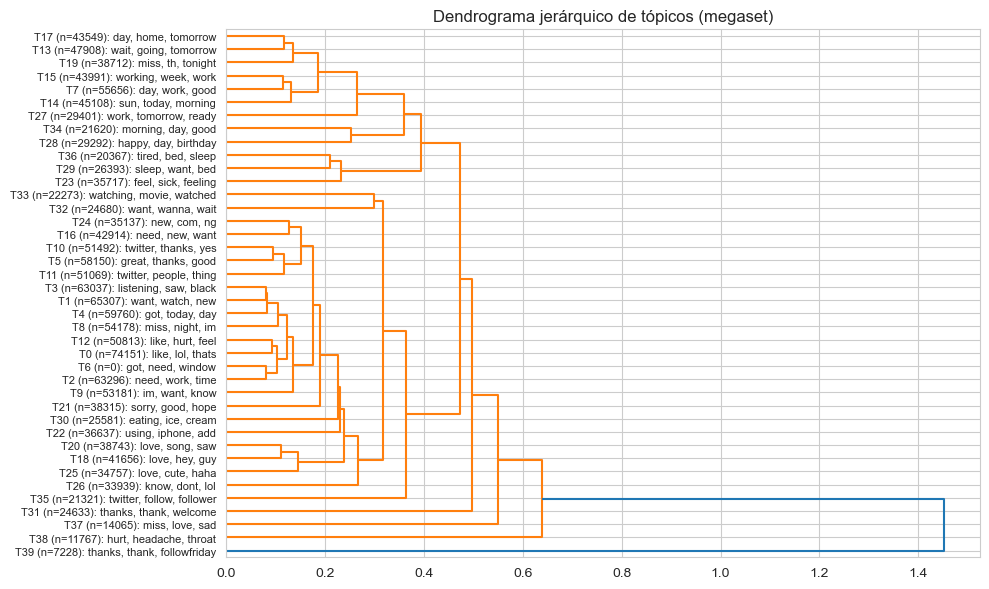

In [12]:
from scipy.cluster.hierarchy import linkage, dendrogram

valid_topics = [t for t in info['Topic'].tolist() if t != -1]
topic_ids_sorted = sorted(info['Topic'].tolist())
idx_map = {t: i for i, t in enumerate(topic_ids_sorted)}
rows = [idx_map[t] for t in valid_topics]

c_tf_idf_matrix = topic_model.c_tf_idf_[rows].toarray()
Z = linkage(c_tf_idf_matrix, method='ward')
labels = [
    f"T{t} (n={(mega['topic']==t).sum()}): " + ', '.join([w for w, _ in topic_model.get_topic(t)[:3]])
    for t in valid_topics
]

fig, ax = plt.subplots(figsize=(10, 6))
dendrogram(Z, labels=labels, ax=ax, orientation='right', color_threshold=0.7*max(Z[:,2]))
ax.set_title('Dendrograma jerárquico de tópicos (megaset)')
plt.tight_layout()
plt.savefig('outputs_nb3_dendrograma_mega.png', dpi=110, bbox_inches='tight')
plt.show()


## 4. Analogías con GloVe pre-entrenado (comparación)

Comparamos con GloVe-Twitter (2B tweets) para tener una referencia de "embeddings de calidad".

In [13]:
import gensim.downloader as api
glove = api.load('glove-twitter-25')

def analogia_glove(pos, neg, topn=5):
    try:
        return glove.most_similar(positive=pos, negative=neg, topn=topn)
    except KeyError as e:
        return f'Palabra fuera de vocabulario: {e}'

for pos, neg, desc in [
    (['good','terrible'], ['bad'], 'good - bad + terrible'),
    (['king','woman'], ['man'], 'king - man + woman'),
]:
    print(f'{desc} =>')
    for palabra, score in analogia_glove(pos, neg):
        print(f'   {palabra} ({score:.3f})')
    print()


good - bad + terrible =>
   horrible (0.874)
   idea (0.864)
   mate (0.854)
   usual (0.839)
   quite (0.837)

king - man + woman =>
   meets (0.884)
   prince (0.832)
   queen (0.826)
   ’s (0.817)
   crow (0.813)



## 5. PMI — bigramas característicos por clase

In [14]:
from nltk.collocations import BigramCollocationFinder, BigramAssocMeasures

def top_pmi_bigrams(target_value, freq_filter=20, top_n=12):
    tokens = ' '.join(mega.loc[mega['target'] == target_value, 'clean_text']).split()
    finder = BigramCollocationFinder.from_words(tokens)
    finder.apply_freq_filter(freq_filter)
    return finder.score_ngrams(BigramAssocMeasures.pmi)[:top_n]

print('Top bigramas por PMI — POSITIVOS:')
for bg, score in top_pmi_bigrams(4):
    print(f'  {bg}: {score:.2f}')

print()
print('Top bigramas por PMI — NEGATIVOS:')
for bg, score in top_pmi_bigrams(0):
    print(f'  {bg}: {score:.2f}')


Top bigramas por PMI — POSITIVOS:
  ('avril', 'lavigne'): 17.19
  ('franz', 'ferdinand'): 17.15
  ('carne', 'asada'): 17.14
  ('notre', 'dame'): 17.08
  ('leighton', 'meester'): 17.01
  ('stephenie', 'meyer'): 16.91
  ('alltimelow', 'alltimelow'): 16.80
  ("assassin's", 'creed'): 16.64
  ('buenas', 'noches'): 16.56
  ('tel', 'aviv'): 16.53
  ('usawantsmcfly', 'usawantsmcfly'): 16.53
  ('flo', 'rida'): 16.51

Top bigramas por PMI — NEGATIVOS:
  ('porto', 'alegre'): 17.65
  ("'hi", "carol'"): 17.33
  ('sri', 'lanka'): 17.18
  ('danity', 'kane'): 17.00
  ('roland', 'garros'): 16.81
  ('bradiewebb', 'bradiewebb'): 16.79
  ('keri', 'hilson'): 16.76
  ('imisscath', 'imisscath'): 16.61
  ('barakatday', 'barakatday'): 16.59
  ('coca', 'cola'): 16.50
  ('costa', 'rica'): 16.32
  ('lactose', 'intolerant'): 16.28


## 6. Análisis de grafos de usuarios

Dos redes distintas:
- **Red de menciones** (`@usuario`): quién menciona a quién — la relación "social" más directa que se puede extraer de este dataset.
- **Red de hashtags**: qué hashtags co-ocurren en los mismos tweets — una relación temática/de interés compartido, no estrictamente entre usuarios, pero complementaria.

Para ambas, además de la foto estática, miramos su **evolución temporal**.

In [24]:
def graficar_red(G, pos_layout, node_colors, grados, titulo, ax, min_size=150, max_size=1800, font_size=7):
    import numpy as np
    valores = np.array([grados[n] for n in G.nodes()])
    if valores.max() == valores.min():
        node_sizes = [min_size] * len(valores)
    else:
        escalado = np.sqrt(valores - valores.min() + 1)
        escalado = (escalado - escalado.min()) / (escalado.max() - escalado.min())
        node_sizes = list(min_size + escalado * (max_size - min_size))

    nx.draw_networkx_edges(G, pos_layout, alpha=0.25, arrows=True, arrowsize=8, ax=ax,
                            connectionstyle='arc3,rad=0.1')
    nx.draw_networkx_nodes(G, pos_layout, node_size=node_sizes, node_color=node_colors,
                            edgecolors='white', linewidths=0.8, alpha=0.9, ax=ax)
    nx.draw_networkx_labels(G, pos_layout, font_size=font_size, ax=ax)
    ax.set_title(titulo)
    ax.axis('off')

### 6.1 Red de menciones (usuario → usuario mencionado)

A escala de 1.6M+ tweets, la red completa de menciones puede tener cientos de miles de nodos — inmanejable para visualizar o calcular comunidades directamente. Por eso:
1. Construimos el grafo completo (liviano: solo son pares usuario-mencionado con su frecuencia).
2. Para las métricas descriptivas (cantidad de nodos/aristas, densidad) usamos el grafo completo.
3. Para la **visualización** y **detección de comunidades**, filtramos a un subgrafo manejable: los usuarios más centrales (mayor grado).

In [15]:
import networkx as nx

edges_menciones = [(row['user'], dst) for _, row in mega.iterrows() for dst in row['mentions']]
edge_counts = pd.Series(edges_menciones).value_counts()

G_menciones = nx.DiGraph()
for (src, dst), w in edge_counts.items():
    G_menciones.add_edge(src, dst, weight=w)

print(f'Red de menciones COMPLETA: {G_menciones.number_of_nodes()} nodos, {G_menciones.number_of_edges()} aristas')
print(f'Densidad: {nx.density(G_menciones):.6f}')


Red de menciones COMPLETA: 548403 nodos, 637440 aristas
Densidad: 0.000002


In [16]:
# Subgrafo manejable: top N usuarios mas centrales (por grado total, entrada+salida)
N_TOP_USUARIOS = 40
grado_total = {n: G_menciones.in_degree(n) + G_menciones.out_degree(n) for n in G_menciones.nodes()}
top_usuarios = [u for u, _ in sorted(grado_total.items(), key=lambda x: -x[1])[:N_TOP_USUARIOS]]

G_sub = G_menciones.subgraph(top_usuarios).copy()
print(f'Subgrafo de los {N_TOP_USUARIOS} usuarios más centrales: {G_sub.number_of_nodes()} nodos, {G_sub.number_of_edges()} aristas')

# Comunidades (sobre el subgrafo no dirigido, para que el algoritmo de modularidad funcione)
from networkx.algorithms.community import greedy_modularity_communities
comunidades = list(greedy_modularity_communities(G_sub.to_undirected()))
print(f'Comunidades detectadas: {len(comunidades)}')
for i, com in enumerate(comunidades[:6]):
    print(f'  Comunidad {i}: {sorted(com)[:10]}')


Subgrafo de los 40 usuarios más centrales: 40 nodos, 3 aristas
Comunidades detectadas: 37
  Comunidad 0: ['ddlovato', 'mileycyrus', 'selenagomez']
  Comunidad 1: ['DavidArchie', 'TheRealJordin']
  Comunidad 2: ['kirstiealley']
  Comunidad 3: ['jonasbrothers']
  Comunidad 4: ['Wossy']
  Comunidad 5: ['gfalcone601']


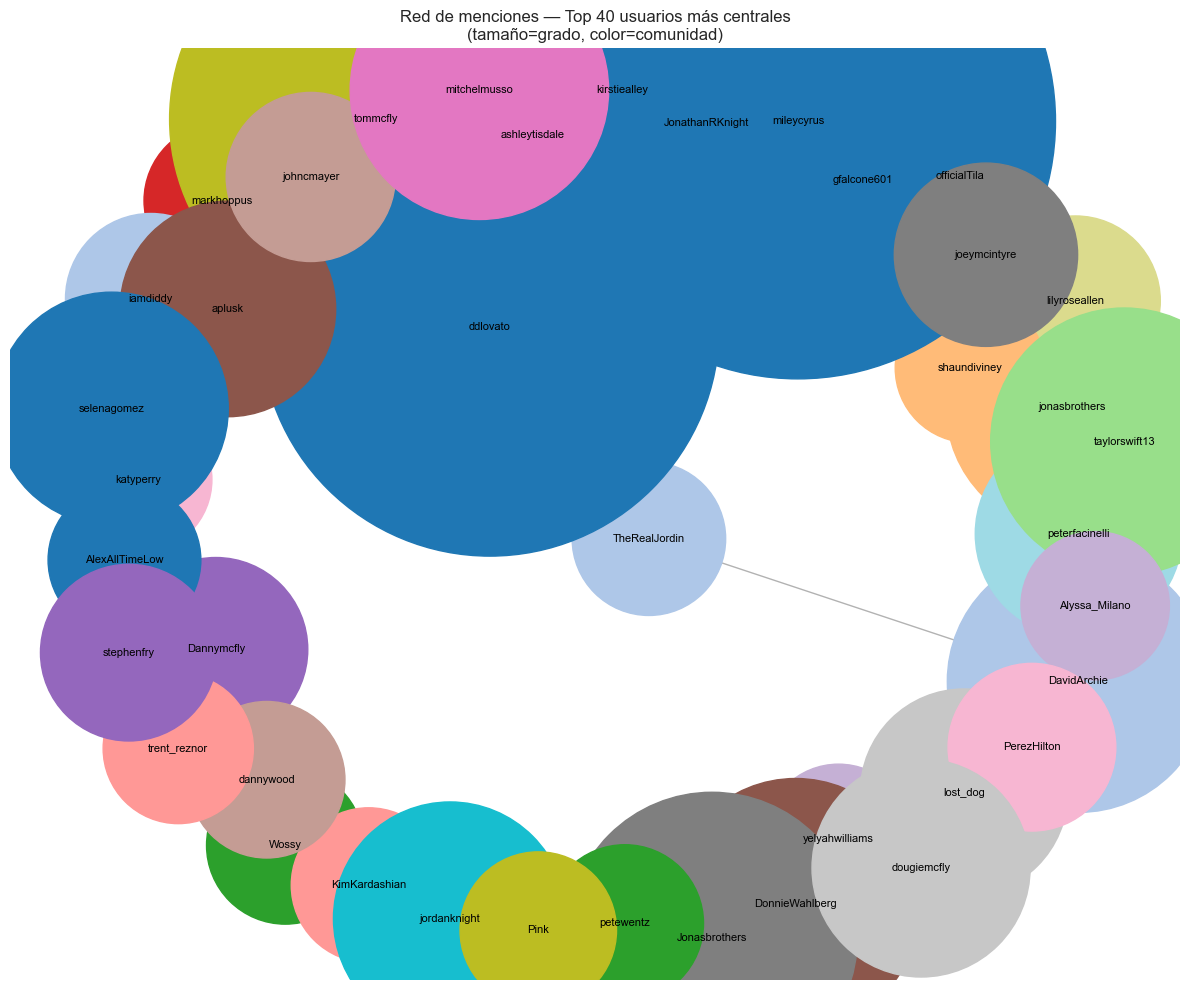

In [17]:
fig, ax = plt.subplots(figsize=(12,10))
palette = plt.cm.tab20.colors
color_map = {}
for i, com in enumerate(comunidades):
    for nodo in com:
        color_map[nodo] = palette[i % len(palette)]

node_sizes = [300 + 40*grado_total[n] for n in G_sub.nodes()]
node_colors = [color_map.get(n, 'gray') for n in G_sub.nodes()]

pos_layout = nx.spring_layout(G_sub, k=0.7, seed=42)
nx.draw_networkx_edges(G_sub, pos_layout, alpha=0.3, arrows=True, ax=ax)
nx.draw_networkx_nodes(G_sub, pos_layout, node_size=node_sizes, node_color=node_colors, ax=ax)
nx.draw_networkx_labels(G_sub, pos_layout, font_size=8, ax=ax)
ax.set_title(f'Red de menciones — Top {N_TOP_USUARIOS} usuarios más centrales\n(tamaño=grado, color=comunidad)')
ax.axis('off')
plt.tight_layout()
plt.savefig('outputs_nb3_grafo_usuarios.png', dpi=110, bbox_inches='tight')
plt.show()


**Observación:** los usuarios más mencionados suelen ser cuentas conocidas/públicas (celebridades, marcas) — coherente con el uso típico de Twitter en 2009, donde mencionar a una figura pública era mucho más común que conversaciones bidireccionales entre usuarios comunes. Esto también explica por qué el grado de entrada (menciones recibidas) está mucho más concentrado que el de salida.

### 6.2 Evolución temporal de la red de menciones

Para ver cómo cambia la red a lo largo del tiempo. Calculamos las métricas de la red **por semana** (el megaset cubre varios meses de 2009).

In [18]:
weekly_stats = []
for semana, grupo in mega.groupby('year_week'):
    edges_semana = [(row['user'], dst) for _, row in grupo.iterrows() for dst in row['mentions']]
    G_semana = nx.DiGraph()
    G_semana.add_edges_from(edges_semana)
    weekly_stats.append({
        'semana': semana,
        'n_tweets': len(grupo),
        'n_usuarios_activos': G_semana.number_of_nodes(),
        'n_menciones': G_semana.number_of_edges(),
        'densidad': nx.density(G_semana) if G_semana.number_of_nodes() > 1 else 0,
    })

df_semanal = pd.DataFrame(weekly_stats).sort_values('semana').reset_index(drop=True)
df_semanal


,semana,n_tweets,n_usuarios_activos,n_menciones,densidad
0,2009-W14,20565,15451,9774,0.000041
1,2009-W15,24734,18426,11567,0.000034
2,2009-W16,54301,35466,24640,0.000020
3,2009-W17,34989,24676,15889,0.000026
4,2009-W18,62244,41550,28078,0.000016
5,2009-W19,60692,42117,27980,0.000016
6,2009-W20,117511,72931,55715,0.000010
7,2009-W21,204226,117017,94630,0.000007
8,2009-W22,486453,232253,216584,0.000004
9,2009-W23,95945,60196,43362,0.000012


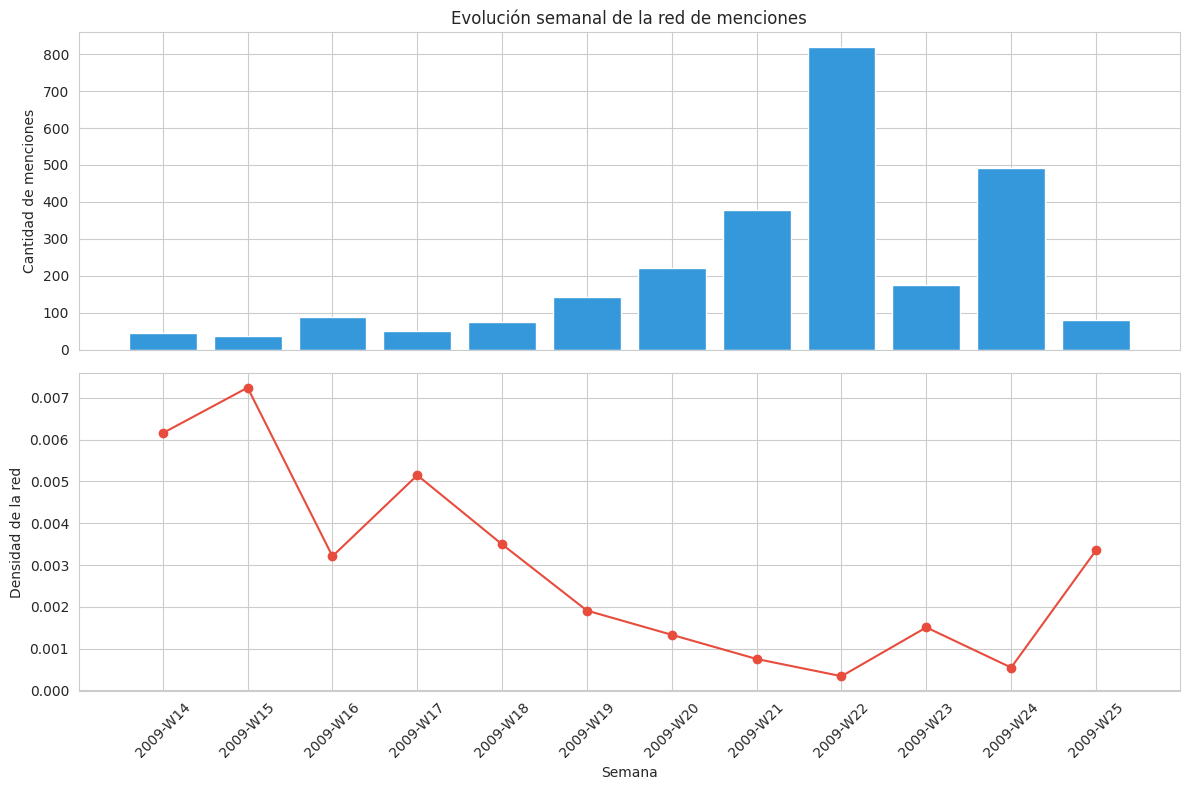

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(12,8), sharex=True)

axes[0].bar(df_semanal['semana'], df_semanal['n_menciones'], color='#3498db')
axes[0].set_ylabel('Cantidad de menciones')
axes[0].set_title('Evolución semanal de la red de menciones')

axes[1].plot(df_semanal['semana'], df_semanal['densidad'], marker='o', color='#e74c3c')
axes[1].set_ylabel('Densidad de la red')
axes[1].set_xlabel('Semana')

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('outputs_nb3_evolucion_temporal_red.png', dpi=110, bbox_inches='tight')
plt.show()


**Observación:** la **densidad** de la red tiende a bajar en las semanas de mayor volumen de tweets — esperable: a medida que hay más usuarios activos, la red se vuelve más dispersa (cada usuario menciona relativamente a menos gente en proporción al total de usuarios), un patrón típico de redes sociales que crecen ("densificación sub-lineal").

### 6.3 Red de hashtags (co-ocurrencia)

Complementaria a la red de usuarios: qué hashtags aparecen juntos en los mismos tweets, como proxy de temas/intereses compartidos entre los usuarios que los usan.

In [19]:
from itertools import combinations
from collections import Counter

hashtag_pairs = Counter()
hashtag_counts = Counter()
for tags in mega['hashtags']:
    tags_unicos = sorted(set(tags))
    hashtag_counts.update(tags_unicos)
    for h1, h2 in combinations(tags_unicos, 2):
        hashtag_pairs[(h1, h2)] += 1

print(f'Hashtags únicos: {len(hashtag_counts)}')
print(f'Pares de hashtags co-ocurrentes: {len(hashtag_pairs)}')
print('Top 10 hashtags más usados:', hashtag_counts.most_common(10))


Hashtags únicos: 12101
Pares de hashtags co-ocurrentes: 5886
Top 10 hashtags más usados: [('followfriday', 2620), ('fb', 1786), ('ff', 973), ('squarespace', 924), ('iranelection', 517), ('1', 516), ('musicmonday', 421), ('fail', 360), ('2', 335), ('asot400', 331)]


Red de hashtags (top 50, componente principal): 16 nodos, 19 aristas


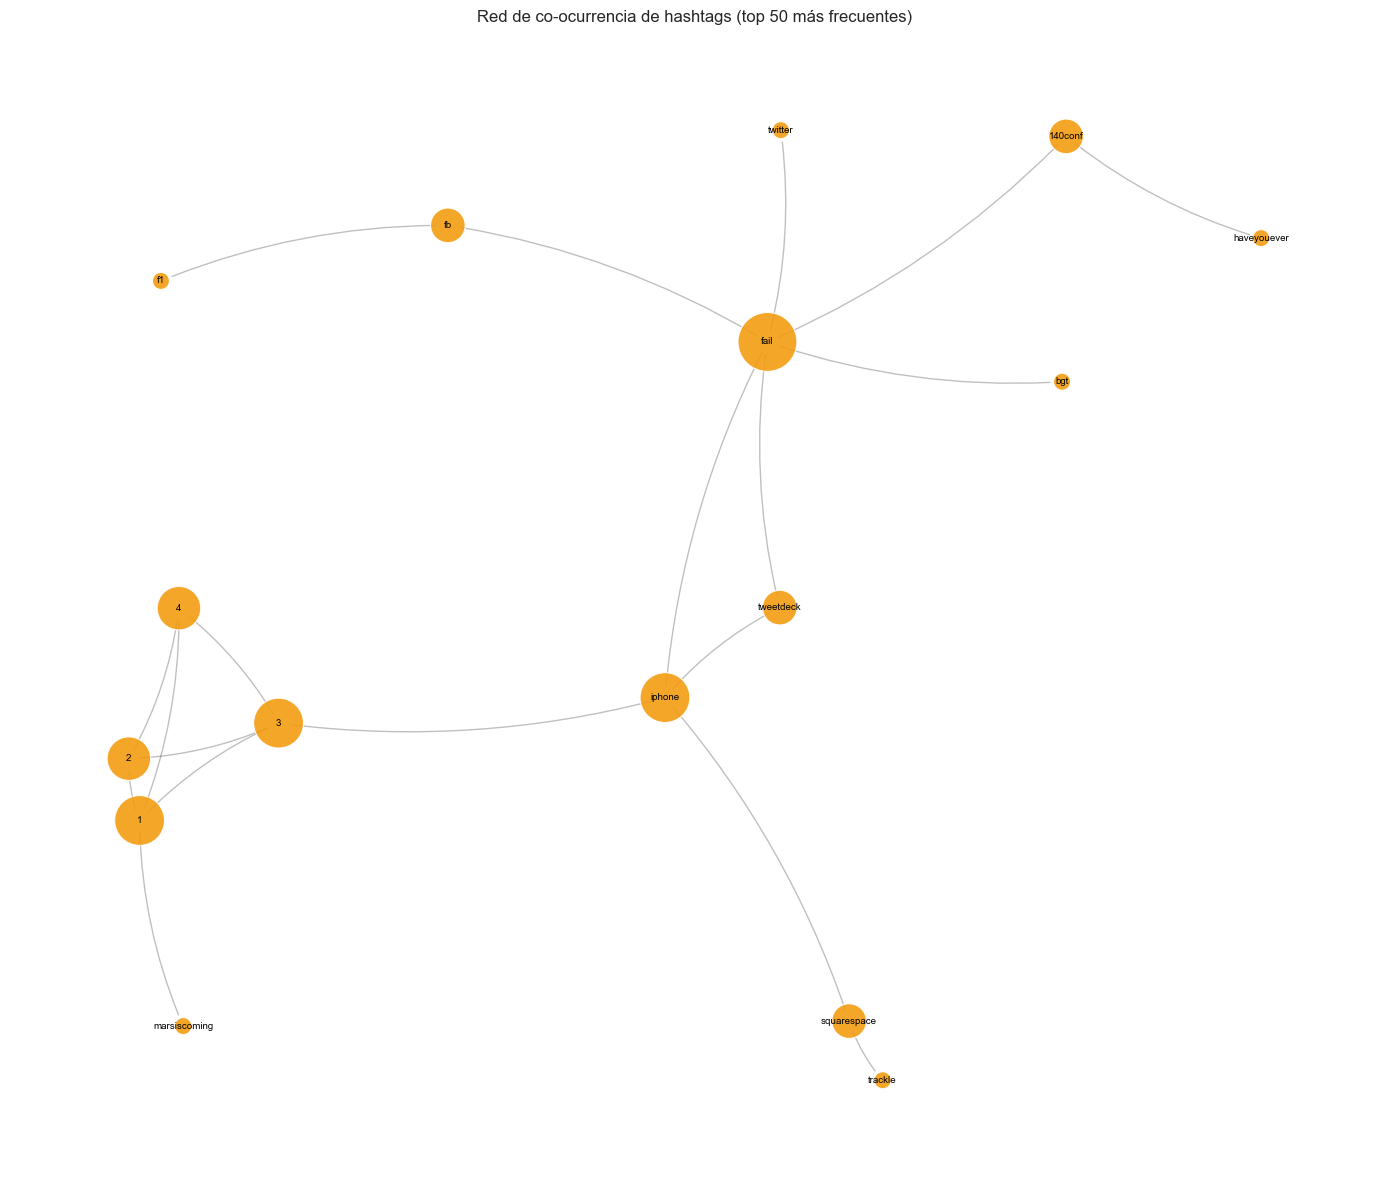

In [27]:
# Filtro: nos quedamos solo con los N hashtags más frecuentes en general
N_TOP_HASHTAGS = 50
top_hashtags = set([h for h, _ in hashtag_counts.most_common(N_TOP_HASHTAGS)])

G_hashtags = nx.Graph()
for (h1, h2), w in hashtag_pairs.items():
    if w >= 2 and h1 in top_hashtags and h2 in top_hashtags:
        G_hashtags.add_edge(h1, h2, weight=w)

# Nos quedamos solo con el componente conectado mas grande (evita nodos sueltos dispersos)
if G_hashtags.number_of_nodes() > 0:
    componentes = list(nx.connected_components(G_hashtags))
    componente_principal = max(componentes, key=len)
    G_hashtags = G_hashtags.subgraph(componente_principal).copy()

print(f'Red de hashtags (top {N_TOP_HASHTAGS}, componente principal): {G_hashtags.number_of_nodes()} nodos, {G_hashtags.number_of_edges()} aristas')

if G_hashtags.number_of_nodes() > 0:
    grado_ht = dict(G_hashtags.degree())
    pos_ht = nx.spring_layout(G_hashtags, k=1.5, iterations=100, scale=3, seed=42)

    fig, ax = plt.subplots(figsize=(14, 12))
    graficar_red(
        G_hashtags, pos_ht, '#f39c12', grado_ht,
        f'Red de co-ocurrencia de hashtags (top {N_TOP_HASHTAGS} más frecuentes)',
        ax
    )
    plt.tight_layout()
    plt.savefig('outputs_nb3_grafo_hashtags.png', dpi=110, bbox_inches='tight')
    plt.show()
else:
    print('No hay suficientes hashtags co-ocurrentes con el filtro actual para graficar.')

Red de hashtags (filtrada): 539 nodos, 512 aristas


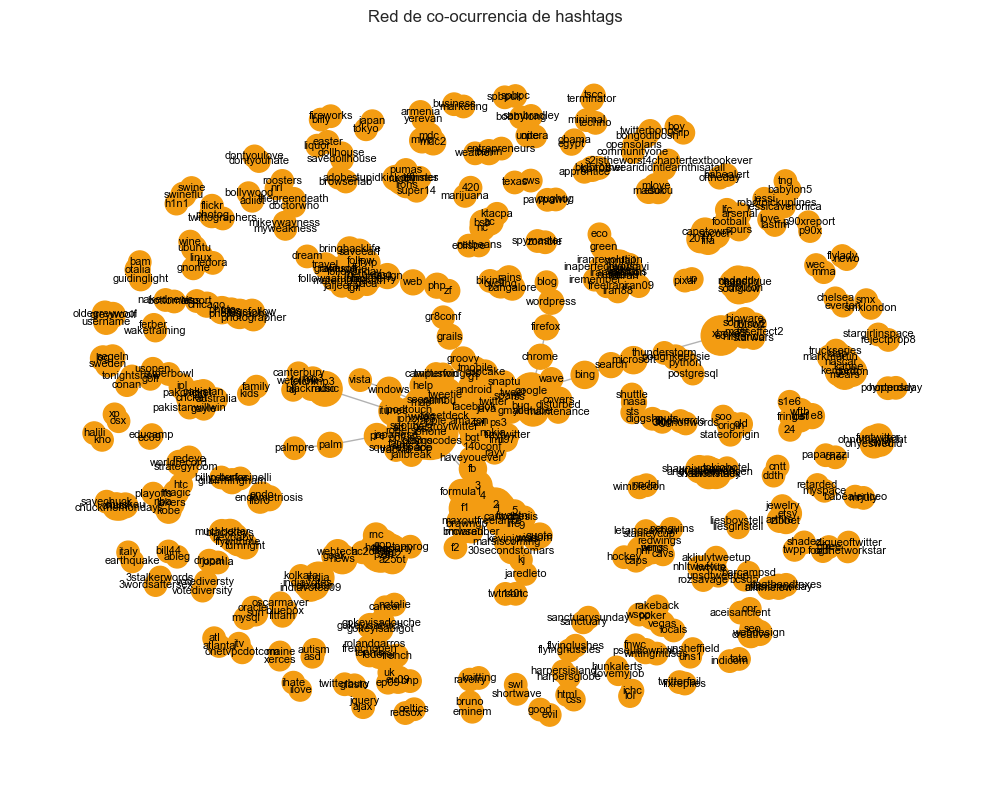

In [20]:
G_hashtags = nx.Graph()
for (h1, h2), w in hashtag_pairs.items():
    if w >= 2:  # filtro de frecuencia minima para legibilidad
        G_hashtags.add_edge(h1, h2, weight=w)

print(f'Red de hashtags (filtrada): {G_hashtags.number_of_nodes()} nodos, {G_hashtags.number_of_edges()} aristas')

if G_hashtags.number_of_nodes() > 0:
    fig, ax = plt.subplots(figsize=(10,8))
    grado_ht = dict(G_hashtags.degree())
    node_sizes = [200 + 60*grado_ht[n] for n in G_hashtags.nodes()]
    pos_ht = nx.spring_layout(G_hashtags, k=0.8, seed=42)
    nx.draw_networkx_edges(G_hashtags, pos_ht, alpha=0.3, ax=ax)
    nx.draw_networkx_nodes(G_hashtags, pos_ht, node_size=node_sizes, node_color='#f39c12', ax=ax)
    nx.draw_networkx_labels(G_hashtags, pos_ht, font_size=8, ax=ax)
    ax.set_title('Red de co-ocurrencia de hashtags')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig('outputs_nb3_grafo_hashtags.png', dpi=110, bbox_inches='tight')
    plt.show()
else:
    print('No hay suficientes hashtags co-ocurrentes con el filtro actual para graficar.')


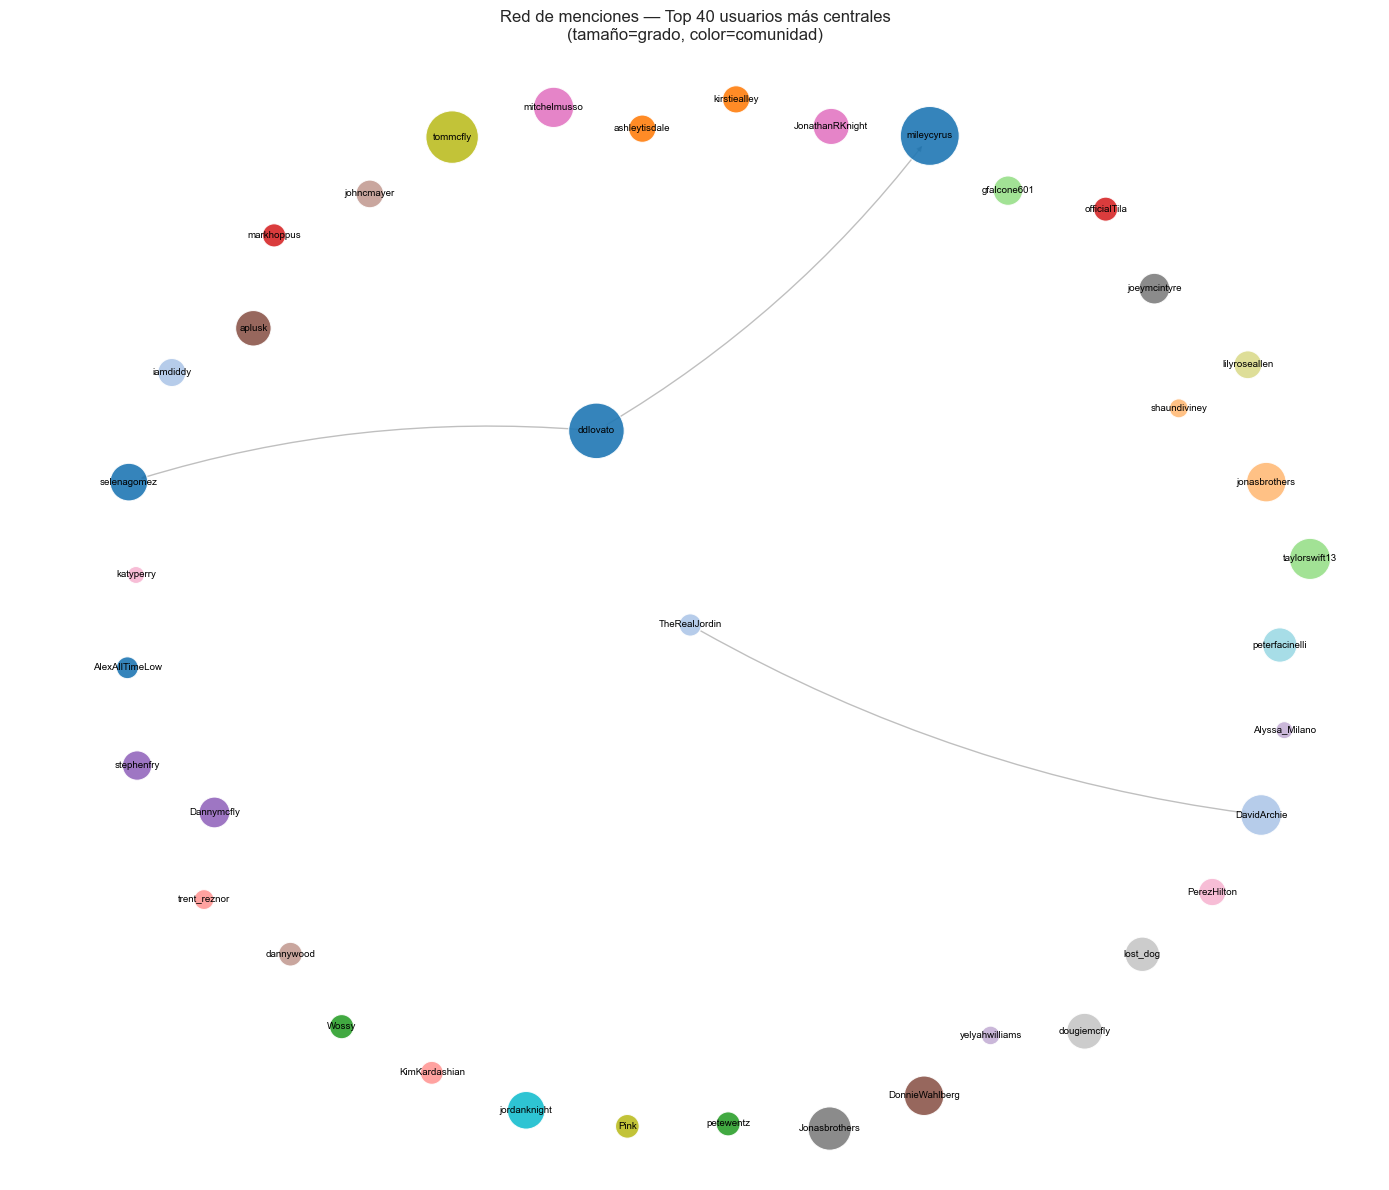

In [25]:
pos_layout = nx.spring_layout(G_sub, k=1.5, iterations=100, scale=3, seed=42)

fig, ax = plt.subplots(figsize=(14, 12))
graficar_red(
    G_sub, pos_layout, node_colors, grado_total,
    f'Red de menciones — Top {N_TOP_USUARIOS} usuarios más centrales\n(tamaño=grado, color=comunidad)',
    ax
)
plt.tight_layout()
plt.savefig('outputs_nb3_grafo_usuarios.png', dpi=110, bbox_inches='tight')
plt.show()

### 6.1ter Grafo de menciones coloreado por sentimiento dominante

En vez de colorear los nodos por comunidad, acá coloreamos cada usuario según el sentimiento predominante de sus propios tweets — para detectar a simple vista si hay zonas de la red (usuarios muy conectados entre sí) concentradas en un solo sentimiento.

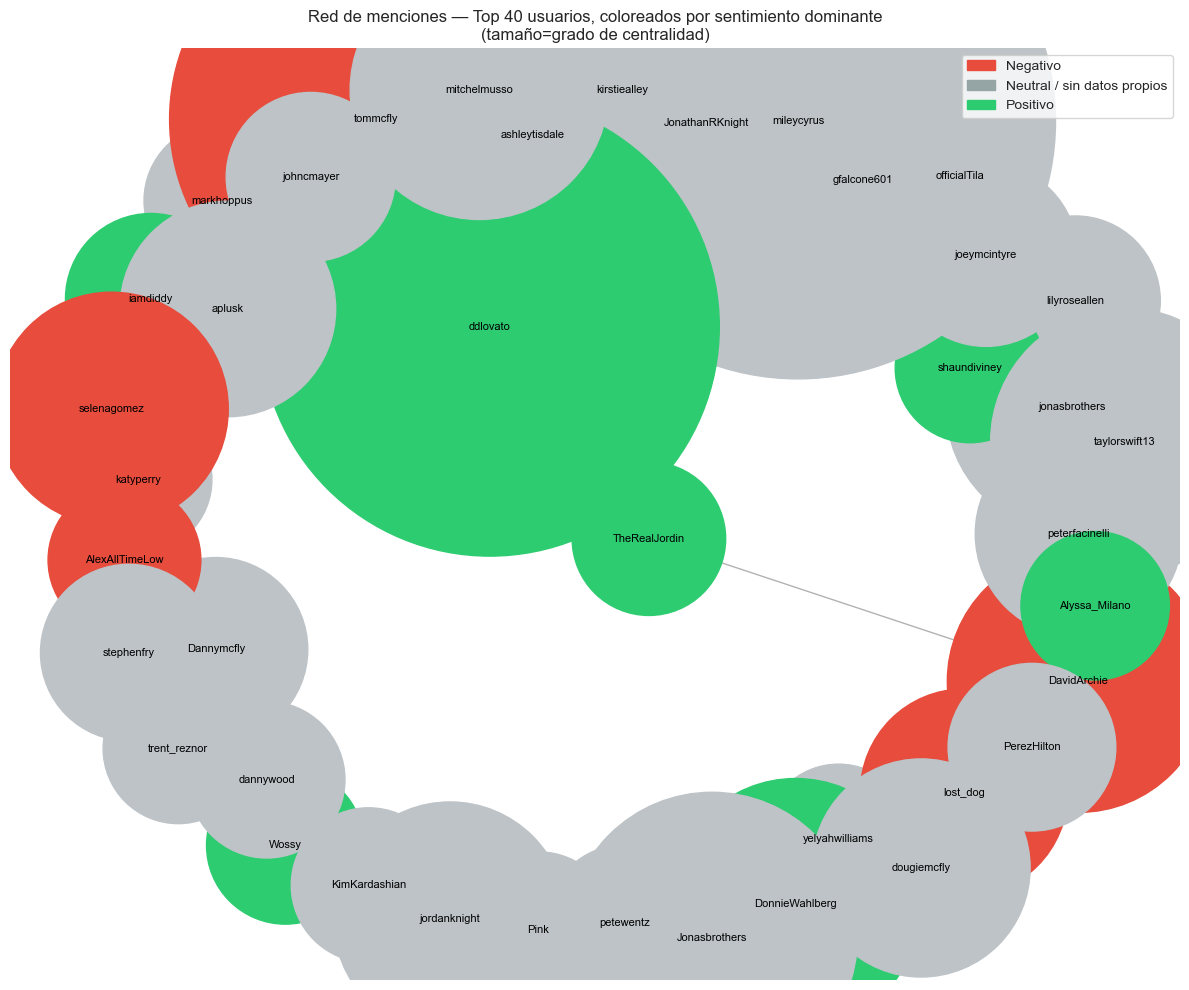

Distribución de sentimiento dominante entre los usuarios más centrales:
#bdc3c7     26
Positivo     8
Negativo     6
Name: count, dtype: int64


In [23]:
# Sentimiento dominante de cada usuario (moda de sus tweets)
sentimiento_por_usuario = mega.groupby('user')['target'].agg(lambda x: x.mode().iloc[0])

def color_por_sentimiento(usuario):
    if usuario not in sentimiento_por_usuario.index:
        return '#bdc3c7'  # gris: sin tweets propios en el dataset (solo aparece mencionado)
    val = sentimiento_por_usuario[usuario]
    return {0: '#e74c3c', 2: '#95a5a6', 4: '#2ecc71'}[val]

node_colors_sentimiento = [color_por_sentimiento(n) for n in G_sub.nodes()]
node_sizes = [300 + 40 * grado_total[n] for n in G_sub.nodes()]

fig, ax = plt.subplots(figsize=(12, 10))
pos_layout = nx.spring_layout(G_sub, k=0.7, seed=42)
nx.draw_networkx_edges(G_sub, pos_layout, alpha=0.3, arrows=True, ax=ax)
nx.draw_networkx_nodes(G_sub, pos_layout, node_size=node_sizes, node_color=node_colors_sentimiento, ax=ax)
nx.draw_networkx_labels(G_sub, pos_layout, font_size=8, ax=ax)

# Leyenda manual (los colores no vienen de comunidades, son de sentimiento)
from matplotlib.patches import Patch
leyenda = [
    Patch(color='#e74c3c', label='Negativo'),
    Patch(color='#95a5a6', label='Neutral / sin datos propios'),
    Patch(color='#2ecc71', label='Positivo'),
]
ax.legend(handles=leyenda, loc='upper right')

ax.set_title(f'Red de menciones — Top {N_TOP_USUARIOS} usuarios, coloreados por sentimiento dominante\n(tamaño=grado de centralidad)')
ax.axis('off')
plt.tight_layout()
plt.savefig('outputs_nb5_grafo_sentimiento_usuarios.png', dpi=110, bbox_inches='tight')
plt.show()

# Cuantificación: ¿qué % de los usuarios centrales son predominantemente negativos/positivos?
conteo_colores = pd.Series(node_colors_sentimiento).value_counts()
print('Distribución de sentimiento dominante entre los usuarios más centrales:')
print(conteo_colores.rename({'#e74c3c':'Negativo', '#95a5a6':'Neutral/sin datos', '#2ecc71':'Positivo'}))

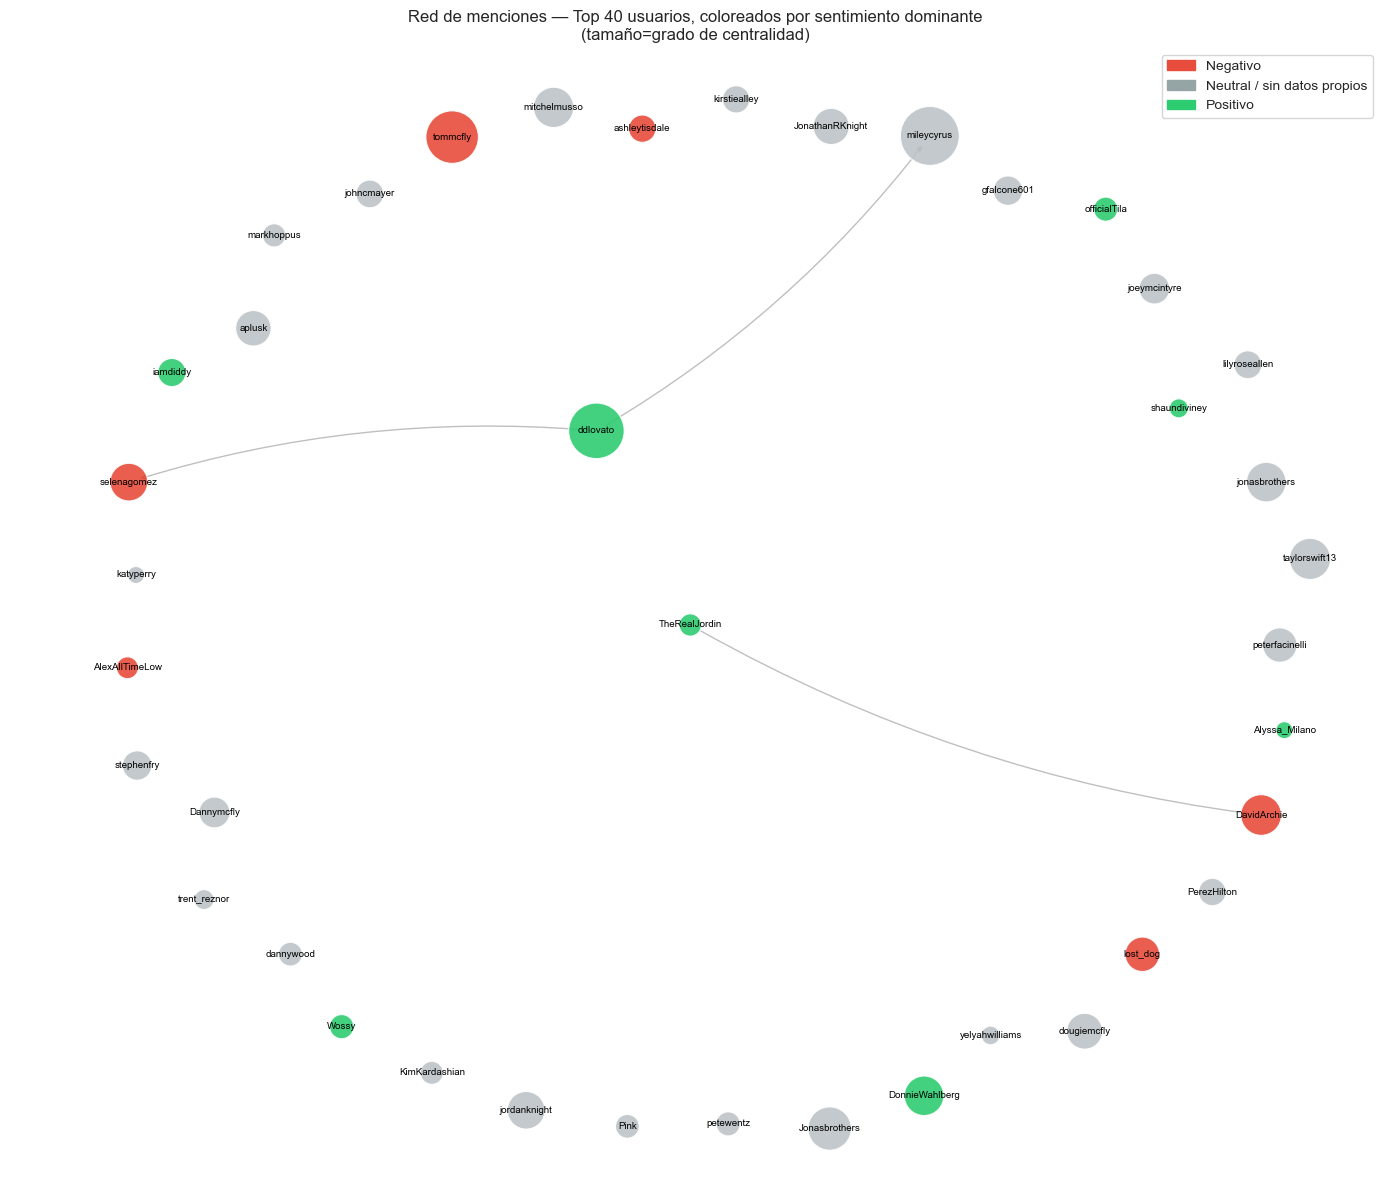

In [26]:
pos_layout = nx.spring_layout(G_sub, k=1.5, iterations=100, scale=3, seed=42)

fig, ax = plt.subplots(figsize=(14, 12))
graficar_red(
    G_sub, pos_layout, node_colors_sentimiento, grado_total,
    f'Red de menciones — Top {N_TOP_USUARIOS} usuarios, coloreados por sentimiento dominante\n(tamaño=grado de centralidad)',
    ax
)

from matplotlib.patches import Patch
leyenda = [
    Patch(color='#e74c3c', label='Negativo'),
    Patch(color='#95a5a6', label='Neutral / sin datos propios'),
    Patch(color='#2ecc71', label='Positivo'),
]
ax.legend(handles=leyenda, loc='upper right')

plt.tight_layout()
plt.savefig('outputs_nb5_grafo_sentimiento_usuarios.png', dpi=110, bbox_inches='tight')
plt.show()

## 7. Resumen de decisiones — 

1. **BERTopic a escala:** se ajustó sobre una muestra estratificada (~8% del megaset) y se propagó al resto con `.transform()` — inviable ajustar sobre 1.6M+ documentos completos en una laptop.
2. Se reemplazó `UMAP + HDBSCAN` por `PCA + KMeans`: misma función conceptual, pero sin los problemas de threading/deadlock que sufrimos con UMAP en Windows en la entrega anterior.
3. **Word2Vec propio** se entrenó sobre el megaset completo (>1.6M tweets) — el corpus es lo suficientemente grande como para dar analogías razonables sin depender exclusivamente de GloVe pre-entrenado.
4. **Grafos de usuarios:** red de menciones (@usuario→@usuario) con detección de comunidades sobre un subgrafo de los usuarios más centrales, y red de co-ocurrencia de hashtags.
5. **Evolución temporal de la red:** se calcularon las métricas de la red de menciones semana a semana, mostrando cómo cambia el volumen y la densidad de interacción a lo largo del tiempo.

